- Logistic Regression only works well when the data is linearly separable. If the data is not linearly separable, the model may struggle to find a good decision boundary, leading to poor performance. In such cases, other algorithms like Support Vector Machines (SVM) or Decision Trees may be more effective.

- **But in this lesson we will see a trick to make Logistic Regression work even on non-linear data**

- So suppose the original data have 2 features, and a binary target variable. We can create new features by applying polynomial transformations to the original features.

- Suppose we want to fit a degree 2 boundary, we can create new features like:

  - $x_1$, $x_2$, $x_1^2$, $x_2^2$, and $x_1 \cdot x_2$

  - So, we will 

  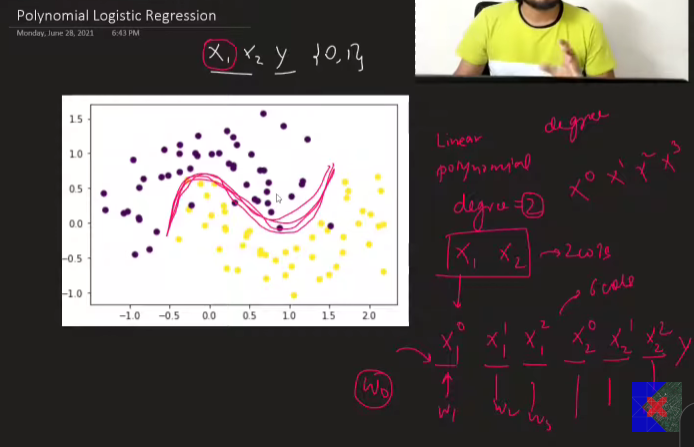

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('ushape.csv')

In [99]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


In [100]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

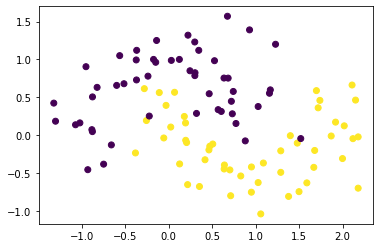

In [101]:
plt.scatter(X[:,0],X[:,1],c=y)

- Using Normal Logistic Regression , this will create a linear decision boundary 

In [102]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [103]:
clf.fit(X,y)

LogisticRegression()

<AxesSubplot:>

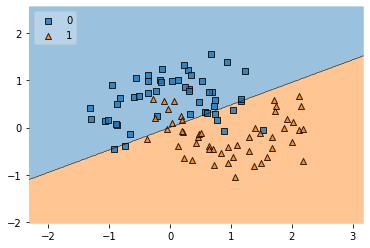

In [104]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf, legend=2)

In [105]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

0.8300000000000001

- Suppose we want to fit a degree 3 boundary:

In [106]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=False)
X_trf = poly.fit_transform(X)

In [107]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

0.9

In [108]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

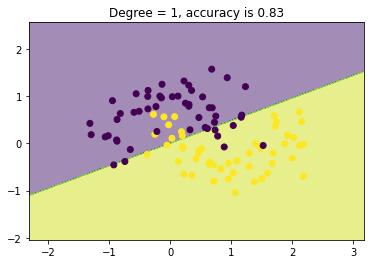

In [109]:
plot_decision_boundary(X,y)

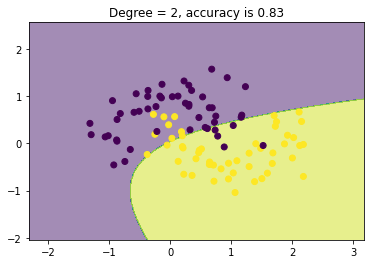

In [110]:
plot_decision_boundary(X,y,degree=2)

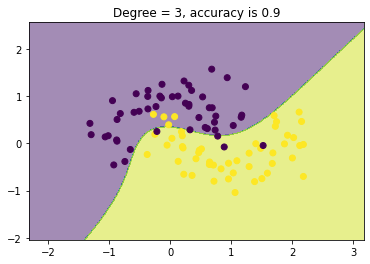

In [111]:
plot_decision_boundary(X,y,degree=3)

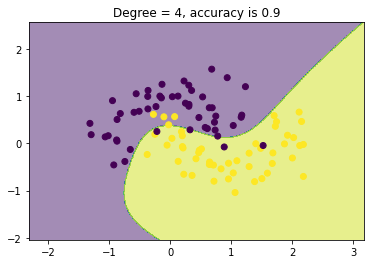

In [112]:
plot_decision_boundary(X,y,degree=4)

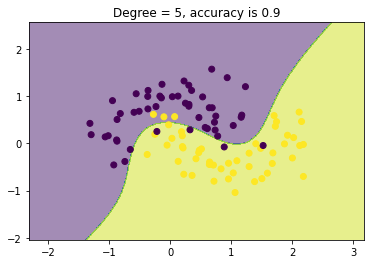

In [113]:
plot_decision_boundary(X,y,degree=5)

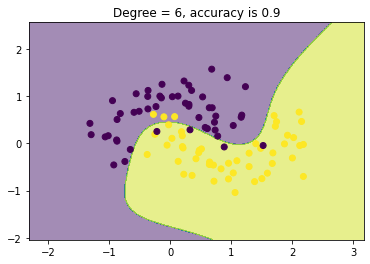

In [114]:
plot_decision_boundary(X,y,degree=6)

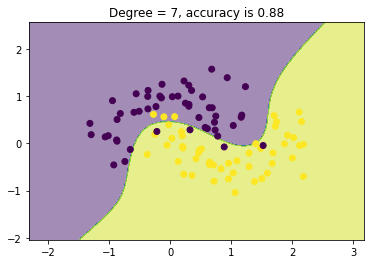

In [115]:
plot_decision_boundary(X,y,degree=7)

C:\Users\91842\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\91842\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

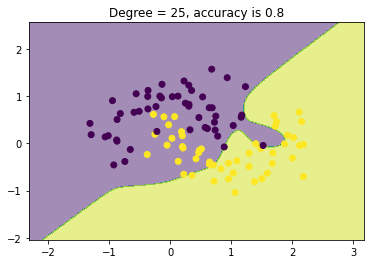

In [116]:
plot_decision_boundary(X,y,degree=25)